# Lab 9: Artificial Neural Network (ANN)
## Objective
Implement a basic Artificial Neural Network (ANN) and evaluate its performance using appropriate metrics.

**Dataset:** Seeds Dataset (Wheat Varieties) — `seeds_dataset.csv`

**Framework:** PyTorch

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0


## 2. Load and Prepare Data

In [2]:
df = pd.read_csv('seeds_dataset.csv')

feature_cols = df.columns[:-1]
X = df[feature_cols].values
y = df['Class'].values

# Encode labels to 0-indexed
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 0, 1, 2

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training: {X_train.shape[0]} samples")
print(f"Testing:  {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")
print(f"Classes:  {len(le.classes_)}")

Training: 168 samples
Testing:  42 samples
Features: 7
Classes:  3


### 2.1 Create PyTorch DataLoaders

In [3]:
# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Create datasets and dataloaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 11
Test batches: 3


## 3. Define ANN Architecture

In [4]:
class SeedClassifierANN(nn.Module):
    def __init__(self, input_size, hidden1_size, hidden2_size, num_classes):
        super(SeedClassifierANN, self).__init__()
        self.network = nn.Sequential(
            # Input layer → Hidden layer 1
            nn.Linear(input_size, hidden1_size),
            nn.BatchNorm1d(hidden1_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Hidden layer 1 → Hidden layer 2
            nn.Linear(hidden1_size, hidden2_size),
            nn.BatchNorm1d(hidden2_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Hidden layer 2 → Output
            nn.Linear(hidden2_size, num_classes)
        )
    
    def forward(self, x):
        return self.network(x)

# Initialize model
input_size = X_train.shape[1]   # 7
hidden1_size = 64
hidden2_size = 32
num_classes = 3

model = SeedClassifierANN(input_size, hidden1_size, hidden2_size, num_classes).to(device)
print("ANN Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

ANN Architecture:
SeedClassifierANN(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=3, bias=True)
  )
)

Total parameters: 2883
Trainable parameters: 2883


## 4. Define Loss Function and Optimizer

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

print(f"Loss Function: CrossEntropyLoss")
print(f"Optimizer: Adam (lr=0.001, weight_decay=1e-4)")
print(f"Scheduler: StepLR (step_size=30, gamma=0.5)")

Loss Function: CrossEntropyLoss
Optimizer: Adam (lr=0.001, weight_decay=1e-4)
Scheduler: StepLR (step_size=30, gamma=0.5)


## 5. Train the ANN

In [6]:
num_epochs = 100
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # Evaluation phase
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    test_loss = test_loss / len(test_loader)
    test_acc = correct / total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    scheduler.step()
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

print(f"\n✅ Training complete!")
print(f"Final Train Accuracy: {train_accuracies[-1]:.4f}")
print(f"Final Test Accuracy:  {test_accuracies[-1]:.4f}")

Epoch [20/100] Train Loss: 0.2508, Train Acc: 0.9226 | Test Loss: 0.2349, Test Acc: 0.9048


Epoch [40/100] Train Loss: 0.1807, Train Acc: 0.9464 | Test Loss: 0.1657, Test Acc: 0.9286


Epoch [60/100] Train Loss: 0.1953, Train Acc: 0.9286 | Test Loss: 0.2007, Test Acc: 0.9286


Epoch [80/100] Train Loss: 0.1417, Train Acc: 0.9643 | Test Loss: 0.1728, Test Acc: 0.9286


Epoch [100/100] Train Loss: 0.1152, Train Acc: 0.9702 | Test Loss: 0.1727, Test Acc: 0.9524

✅ Training complete!
Final Train Accuracy: 0.9702
Final Test Accuracy:  0.9524


## 6. Training History Visualization

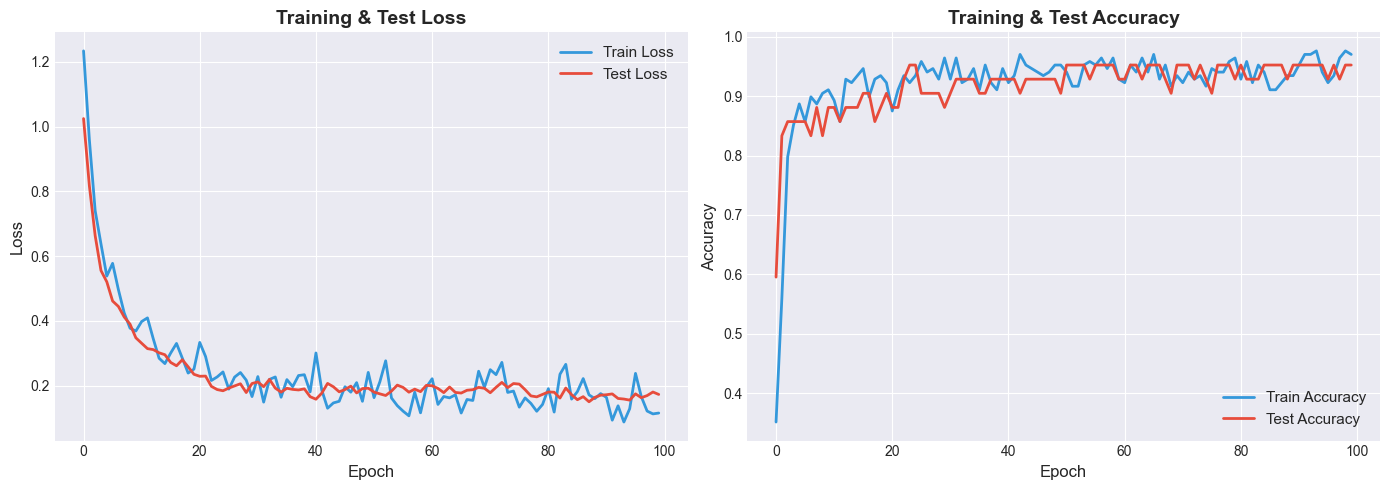

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Test Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)

# Accuracy
axes[1].plot(train_accuracies, label='Train Accuracy', color='#3498db', linewidth=2)
axes[1].plot(test_accuracies, label='Test Accuracy', color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training & Test Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

## 7. Evaluate the ANN

In [8]:
# Get predictions
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, y_pred = torch.max(outputs, 1)
    y_pred = y_pred.cpu().numpy()
    y_true = y_test

# Metrics
class_names = ['Kama', 'Rosa', 'Canadian']

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("ANN — Evaluation Metrics")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

ANN — Evaluation Metrics
Accuracy:  0.9524
Precision: 0.9583
Recall:    0.9524
F1 Score:  0.9521

Classification Report:
              precision    recall  f1-score   support

        Kama       1.00      0.86      0.92        14
        Rosa       1.00      1.00      1.00        14
    Canadian       0.88      1.00      0.93        14

    accuracy                           0.95        42
   macro avg       0.96      0.95      0.95        42
weighted avg       0.96      0.95      0.95        42



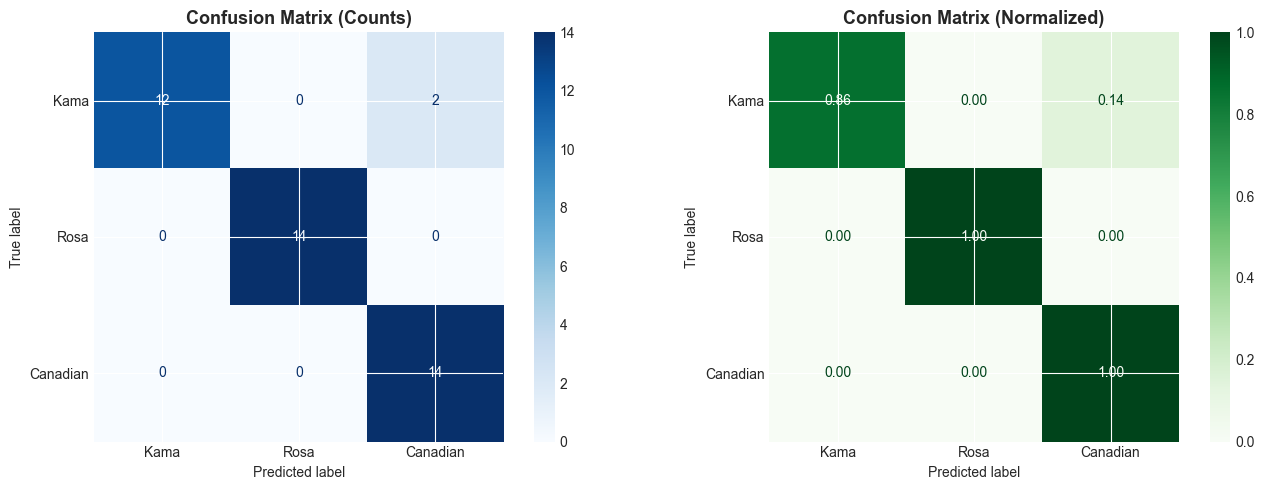

In [9]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')

cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp_norm.plot(cmap='Greens', ax=axes[1], values_format='.2f')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Prediction Probabilities

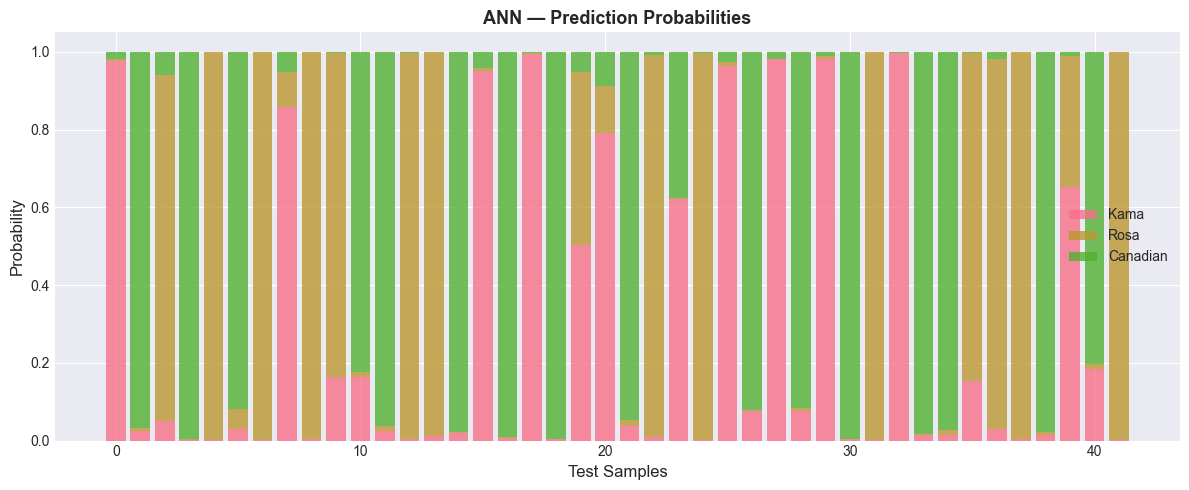

In [10]:
# Get prediction probabilities using softmax
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    probabilities = torch.softmax(outputs, dim=1).cpu().numpy()

fig, ax = plt.subplots(figsize=(12, 5))
x_idx = np.arange(len(y_true))

for i, cls_name in enumerate(class_names):
    ax.bar(x_idx, probabilities[:, i], bottom=probabilities[:, :i].sum(axis=1),
           label=cls_name, alpha=0.8)

ax.set_xlabel('Test Samples', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('ANN — Prediction Probabilities', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Model Architecture Summary

In [11]:
print("=" * 60)
print("ANN MODEL SUMMARY")
print("=" * 60)
print(f"\nArchitecture:")
print(f"  Input Layer:    {input_size} neurons (features)")
print(f"  Hidden Layer 1: {hidden1_size} neurons + BatchNorm + ReLU + Dropout(0.3)")
print(f"  Hidden Layer 2: {hidden2_size} neurons + BatchNorm + ReLU + Dropout(0.2)")
print(f"  Output Layer:   {num_classes} neurons (softmax)")
print(f"\nTraining:")
print(f"  Epochs: {num_epochs}")
print(f"  Batch size: 16")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Loss: CrossEntropyLoss")
print(f"\nResults:")
print(f"  Test Accuracy:  {accuracy:.4f}")
print(f"  Test F1 Score:  {f1:.4f}")
print(f"  Total params:   {total_params}")

ANN MODEL SUMMARY

Architecture:
  Input Layer:    7 neurons (features)
  Hidden Layer 1: 64 neurons + BatchNorm + ReLU + Dropout(0.3)
  Hidden Layer 2: 32 neurons + BatchNorm + ReLU + Dropout(0.2)
  Output Layer:   3 neurons (softmax)

Training:
  Epochs: 100
  Batch size: 16
  Optimizer: Adam (lr=0.001)
  Loss: CrossEntropyLoss

Results:
  Test Accuracy:  0.9524
  Test F1 Score:  0.9521
  Total params:   2883


## 10. Conclusion
In this lab, we:
- Built a **feedforward ANN** using PyTorch with 2 hidden layers
- Used **BatchNorm, ReLU, Dropout** for regularization
- Trained with **Adam optimizer** and **CrossEntropyLoss**
- Evaluated using accuracy, precision, recall, F1, and confusion matrix
- Visualized training curves showing convergence of loss and accuracy
- The ANN effectively classifies the 3 wheat varieties from seed measurements